In [1]:
import pandas as pd
import numpy as np
from diff_diff import CallawaySantAnna
import matplotlib.pyplot as plt            # Plotting
import seaborn as sns                      # Heatmap for treatment rollout
from linearmodels.panel import PanelOLS

In [2]:
def cs_simple(df, outcome, time, first_treat, agg, control, entity):
    return CallawaySantAnna(
        control_group=control, estimation_method="dr",
        n_bootstrap=1000, seed=64,                      # multiplier-bootstrap SEs, seeded
        cluster=entity,                                 # cluster the bootstrap at entity level
        ).fit(df, outcome=outcome, unit=entity, time=time, first_treat=first_treat, aggregate=agg)

In [3]:
df = pd.read_csv(r'docs\causal-exercises\2026-08-23-staggered-rollout-did\data.csv')

In [5]:
df.describe()

,store_id,month,cohort_month,orders
count,4800.00000,4800.000000,4800.00000,4800.000000
mean,100.50000,12.500000,9.75000,869.082500
std,57.74032,6.922908,7.04967,97.935481
min,1.00000,1.000000,0.00000,674.000000
25%,50.75000,6.750000,5.25000,792.000000
50%,100.50000,12.500000,10.00000,833.000000
75%,150.25000,18.250000,14.50000,958.000000
max,200.00000,24.000000,19.00000,1152.000000


In [14]:
res = cs_simple(df, "orders", "month", "cohort_month","event_study", "never_treated", "store_id")
print(res.overall_att, res.overall_se, res.overall_conf_int)

177.95000000000002 5.164490635320022 (167.64170166666668, 188.63211333333336)


C:\Users\diego\AppData\Local\Temp\ipykernel_33012\2428906104.py:6: FutureWarning: CallawaySantAnna.fit(aggregate=) is deprecated and will be removed in 4.0. Fit once, then aggregate as a post-fit step: results = CallawaySantAnna().fit(...); results.aggregate('event_study') / .aggregate('group') / .aggregate('simple') / .aggregate('total'). balance_e moves onto aggregate() alongside it: results.aggregate('event_study', balance_e=2).
  ).fit(df, outcome=outcome, unit=entity, time=time, first_treat=first_treat, aggregate=agg)


In [33]:
print(res.summary())

            Callaway-Sant'Anna Staggered Difference-in-Differences Results           

Total observations:                  4800
Treated units:                        150
Never-treated units:                   50
Treatment cohorts:                      3
Time periods:                          24
Control group:                 never_treated
Base period:                      varying

-------------------------------------------------------------------------------------
                   Overall Average Treatment Effect on the Treated                   
-------------------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|   Sig.
-------------------------------------------------------------------------------------
ATT                 177.9500       5.1645     34.456     0.0010    ***
-------------------------------------------------------------------------------------

95% Confidence Interval: [167.6417, 188.63

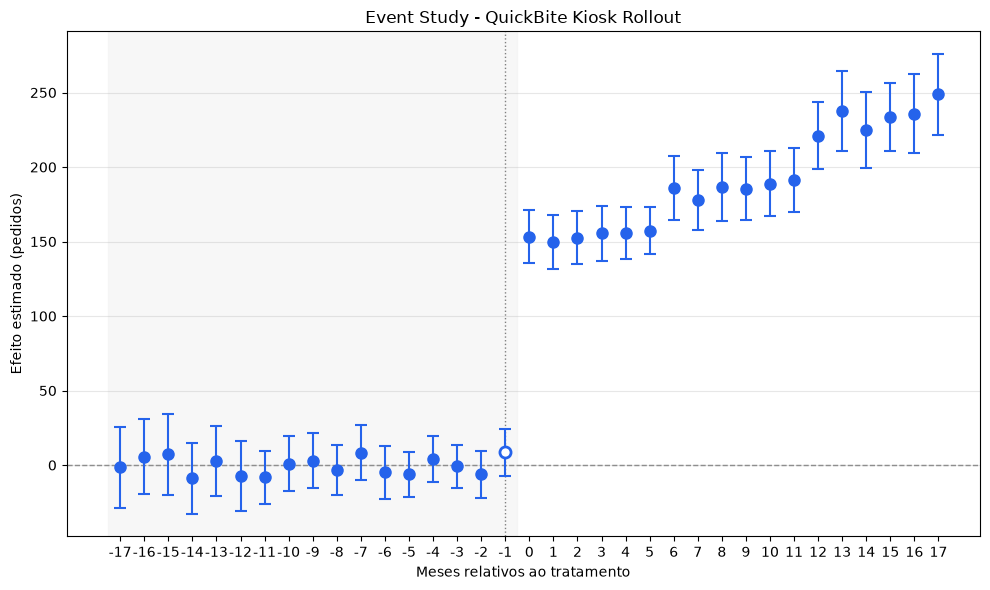

In [31]:
from diff_diff import plot_event_study

ax = plot_event_study(
    res,
    title="Event Study - QuickBite Kiosk Rollout",
    xlabel="Meses relativos ao tratamento",
    ylabel="Efeito estimado (pedidos)",
)

In [23]:
event_study = res.event_study_effects

In [27]:
event_study = dict(event_study)

In [34]:
group_effects = res.aggregate("group")
print(group_effects.summary())

CallawaySantAnna - aggregate(type='group')
         label         ATT         SE        t        p   n[cells]
----------------------------------------------------------------
             7    215.8200     5.8235   37.060   0.0010         18
            13    153.0633     7.1664   21.359   0.0010         12
            19    114.1133     6.2607   18.227   0.0010          6
----------------------------------------------------------------
Confidence intervals at alpha=0.05.
Per-row aggregation weights are not defined for this level.


In [35]:
ax = plot_event_study(
    group_effects,
    title="Event Study - QuickBite Kiosk Rollout",
    xlabel="Meses relativos ao tratamento",
    ylabel="Efeito estimado (pedidos)",
)

TypeError: Cannot extract plot data from AggregationResult. Expected MultiPeriodDiDResults, CallawaySantAnnaResults, SunAbrahamResults, ImputationDiDResults, ChaisemartinDHaultfoeuilleResults, EventStudyResults, or DataFrame.